In [3]:
import pandas as pd
import polars as pl
import seaborn as sns
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Set, List
import pyarrow.parquet as pq

In [6]:
current_dir = Path.cwd()

In [7]:
if (current_dir / "research" / "optimization_results").exists():
    results_dir = current_dir / "research" / "optimization_results"
elif (current_dir / "optimization_results").exists():
    results_dir = current_dir / "optimization_results"
elif (current_dir.parent / "optimization_results").exists():
    results_dir = current_dir.parent / "optimization_results"
else:
    raise FileNotFoundError("🚨 FOLDER 'optimization_results' TIDAK DITEMUKAN! Pastikan shotgun.py sudah selesai dieksekusi.")

print(f"📁 Target folder ditemukan di: {results_dir}")

FileNotFoundError: 🚨 FOLDER 'optimization_results' TIDAK DITEMUKAN! Pastikan shotgun.py sudah selesai dieksekusi.

In [81]:
parquet_files = list(results_dir.glob("quantum_batch_*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"🚨 FOLDER KETEMU, TAPI KOSONG! Belum ada file parquet di {results_dir}.")

In [82]:
latest_file = max(parquet_files, key=lambda p: p.stat().st_mtime)
print(f"📡 Menganalisis file: {latest_file.name}")

📡 Menganalisis file: quantum_batch_20260228_012615.parquet


In [83]:
df = pd.read_parquet(latest_file)
df_success = df[df['status'] ==  'SUCCESS'].copy()

In [84]:
if df_success.empty:
    raise ValueError("🚨 SEMUA EKSPERIMEN GAGAL (STATUS != SUCCESS). Cek terminal lu buat liat error log dari Shotgun!")

In [85]:
df_success['Q'] = df_success['params'].apply(lambda x: x['process_noise'])
df_success['R'] = df_success['params'].apply(lambda x: x['observation_noise'])

In [86]:
df_success['Q_label'] = df_success['Q'].apply(lambda x:f"{x:.1e}")
df_success['R_label'] = df_success['R'].apply(lambda x:f"{x:.1e}")

In [87]:
pivot = df_success.pivot_table(
    index = 'R_label',
    columns = 'Q_label',
    values = 'smart_score',
    aggfunc = 'max'
)

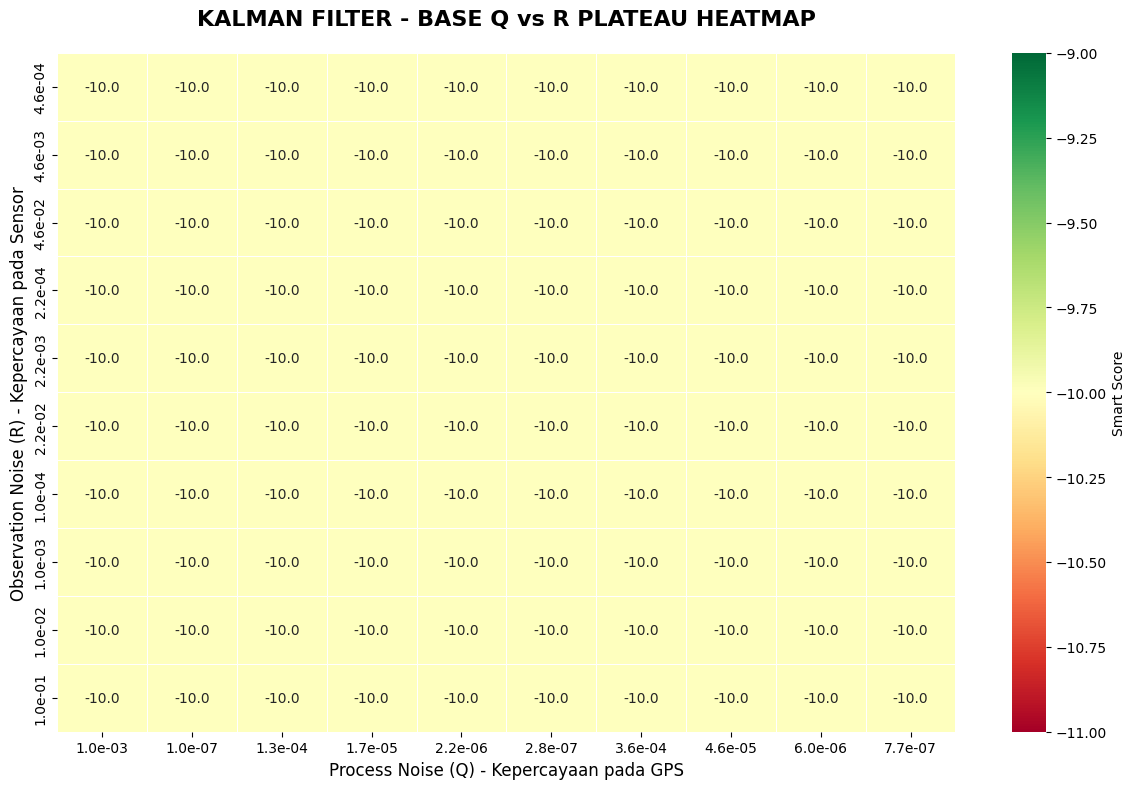

In [88]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot, 
    cmap="RdYlGn", 
    annot=True, 
    fmt=".1f", 
    linewidths=0.5, 
    cbar_kws={'label': 'Smart Score'}  # <--- FIX DI SINI: huruf kecil 'l'
)

plt.title("KALMAN FILTER - BASE Q vs R PLATEAU HEATMAP", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Process Noise (Q) - Kepercayaan pada GPS", fontsize=12)
plt.ylabel("Observation Noise (R) - Kepercayaan pada Sensor", fontsize=12)
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()